# PROJEKT : <span style="margin-left:40px;"> Jerzy Marcin Urbański</span>

##### TEMAT:
## Analiza Jakości Powietrza Dla Wybranych Lokalizacji Oraz Okresów

Importy Bibliotek wraz z ich opisem 

<hr style="border: none; border-top: 11px dotted green;">

Sekcja bibliotek

<hr style="border: none; border-top: 11px dashed black;">

<hr style="
height:6px;
border:none;
background: linear-gradient(to right, red, orange, yellow, green, blue, purple);
">

<div style="
height:50px;
width:100%;
background: linear-gradient(270deg, red, orange, yellow, green, blue, purple);
background-size: 400% 100%;
animation: gradientMove 5s ease infinite;
"></div>

<style>
@keyframes gradientMove {
  0% { background-position: 0% 50%; }
  100% { background-position: 100% 50%; }
}
</style>

In [1046]:
# ### pandas

# Biblioteka do pracy z danymi tabelarycznymi (DataFrame), umożliwia łatwe filtrowanie, grupowanie i przekształcanie danych. 
# Używana głównie do analizy danych, czyszczenia danych oraz wczytywania/zapisywania plików (CSV, Excel, SQL).
import pandas as pd

# ### numpy
# Podstawowa biblioteka do obliczeń numerycznych w Pythonie, oferująca wydajne operacje na tablicach wielowymiarowych. 
# Wykorzystywana do obliczeń matematycznych, statystycznych oraz jako fundament dla innych bibliotek analitycznych.
import numpy as np

# ### os
# Biblioteka standardowa do interakcji z systemem operacyjnym, umożliwia pracę z plikami i katalogami oraz zmiennymi środowiskowymi. 
#Używana m.in. do automatyzacji operacji na plikach i zarządzania ścieżkami.
import os

# ### matplotlib
# Biblioteka do tworzenia wykresów i wizualizacji danych w Pythonie. Pozwala generować różne typy wykresów (liniowe, słupkowe, histogramy) 
# oraz dostosowywać ich wygląd.
import matplotlib.pyplot as plt

# ### seaborn
# Rozszerzenie matplotlib, które upraszcza tworzenie estetycznych i statystycznych wizualizacji danych. 
# Umożliwia szybkie generowanie wykresów takich jak heatmapy, wykresy rozkładu czy zależności między zmiennymi.
import seaborn as sns

# ### ydata_profiling
# Biblioteka do automatycznej analizy eksploracyjnej danych (EDA), generująca szczegółowe raporty o zbiorze danych. 
# Pokazuje statystyki, brakujące wartości, korelacje i potencjalne problemy w danych.
from ydata_profiling import ProfileReport

# ### IPython.display
# Moduł umożliwiający wyświetlanie różnych typów treści w notebookach (HTML, obrazy, wideo). 
#  Używany do wzbogacania prezentacji wyników analiz i tworzenia interaktywnych raportów.
from IPython.display import IFrame

# Moduł do obsługi ścieżek plików
from pathlib import Path

Sekcja bibliotek ML

In [1519]:
# import....

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

from sklearn.dummy import DummyRegressor


from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor 
# pip install xgboost lightgbm
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.multioutput import MultiOutputRegressor



<hr style="
height:50px;
border:none;
background: linear-gradient(to right, red, orange, yellow, green, blue, purple);
">

## STEP 1. Wczytanie danych + transformacja datasetów przygotowanie do głównego połaczenia.
        [ LOAD DATA + PREPROCESSING ]
Import danych z plików csv , ostateczne sprawdznie oraz potrzebna agregacja do ostatecznej wersji.

### 1.1. - DANE - weather_pz/ld_2023/2024

##### 1.1.1. Import wszyskich plików do odpowiednich zmiennych 


In [1053]:
# import wszyskich plików do odpowiednich zmiennych 

w_ld_2023 = pd.read_csv('/Users/marcinurbanski/Desktop/jmu_repo/1_projekt_air_polution_repo/0_ready_raw_data/weather_ld_2023.csv')
w_ld_2024 = pd.read_csv('/Users/marcinurbanski/Desktop/jmu_repo/1_projekt_air_polution_repo/0_ready_raw_data/weather_ld_2024.csv')
w_pz_2023 = pd.read_csv('/Users/marcinurbanski/Desktop/jmu_repo/1_projekt_air_polution_repo/0_ready_raw_data/weather_pz_2023.csv')
w_pz_2024 = pd.read_csv('/Users/marcinurbanski/Desktop/jmu_repo/1_projekt_air_polution_repo/0_ready_raw_data/weather_pz_2024.csv')

In [1054]:
# szybkie sprawdznie 

# display(w_ld_2023.head(2))
# display(w_ld_2024.head(2))
# display(w_pz_2023.head(2))
# display(w_pz_2024.head(2))

#### 1.1.2. Połaczenie w jedne DataFrame

In [1056]:
w_df = pd.concat([w_ld_2023,w_ld_2024,w_pz_2023,w_pz_2024], axis=0 , ignore_index=True)

#### 1.1.2. - Agregacja danych do postaci uniwersalnego DataFrame 

In [1058]:
# przypisanie odpowiedniego id miasta [city] wg współrzędnych

w_df['city'] = w_df['longitude'].map({17.0 : 'PZ' , 19.5 : 'LD'})

In [1059]:
# Selekscja kolumn do usunięcia 

# print(w_ld_2004['step'].nunique()) # kolumna ma jeden wynik -> usunać
# print('-'*140)
# print(w_ld_2004['surface'].nunique()) # kolumna ma jeden wynik -> usunać
# print('-'*140)
# print(w_ld_2004[w_ld_2004["time"] != w_ld_2004["valid_time"]]) # kolumna 'valid_time' powtrza wartosci 'time' -> usunać 
# print('-'*140)
# print(w_ld_2004['number'].nunique())

In [1060]:
# usunięcie niepotrzebnych kolumn ['Unnamed: 0','latitude','longitude','step','surface','valid_time']

w_df = w_df.drop(['Unnamed: 0','latitude','longitude','step','surface','valid_time','number'], axis=1)

In [1061]:
# Zamiana typu danych object z kolumny 'time' na date_time

w_df['time'] = pd.to_datetime(w_df['time'])

Obliczenie prędkości wiatru ze zmiennych u10 & v10 ze wzoru tj z równania pitagorasa
- zmienna u10 => prędkość wiatru zachodniego 
- zmienna v10 => prędkość wiartu północnego 

$$
v_w = \sqrt{u_{10}^2 + v_{10}^2}
$$


In [1063]:
# przeliczenie prędkości wiatru 'v_w' i dodanie jako nowa kolumna z tymi wartościami

w_df['v_w'] = np.sqrt(w_df['u10']**2 + w_df['v10']**2)

In [1064]:
# ułożenie kolejnosci kolumn [info data | zmienne pogodowe] 

col_order = ['city','time','u10', 'v10','v_w','t2m','blh','sp','tcc']
w_df = w_df[col_order]

#### 1.1.4. PODSUMOWANIE PKT. 1.1 DANE POGOWE 
OPIS ZMIENNYCH 
- 'city' -> MIASTO ZAPISANE W SYMOBOLEM
    - PZ = Poznań
    - LD = Łódź 
- 'time'............ DATA GODZINA
- 'u10' -> predkosc wiatru z kierunku / jednostko = [ m/s ] 
- 'v10' -> prędkość wiatru z kierunku / jednostka = [ m/s ]
- 'v_w' -> rzeczywista prędkość wiatru / jednostka = [ m/s ]
- 't2m' -> temperatura powietrze 2m nad poziomem powierzchni / jednostka [ Kelwin ]
- 'blh' -> WYSOKOŚĆ WARSTWY GRANICZNEJ / jednostka [ m ]
- 'sp' -> CIŚNIENIE / jednostka [ Pa ]
- 'tcc' -> CAŁKOWITE ZACHMURZENIE / jednostk [ 0-1 ] [ % ]

    

### 1.2. TABELE CAŁKOWITE OPADY - total_precipition

#### 1.2.1. Import wszyskich plików do odpowiednich zmiennych 

In [1068]:
tp_ld_2004 = pd.read_csv('/Users/marcinurbanski/Desktop/jmu_repo/1_projekt_air_polution_repo/0_ready_raw_data/total_precipitation_ld_2023.csv')
tp_ld_2024 = pd.read_csv('/Users/marcinurbanski/Desktop/jmu_repo/1_projekt_air_polution_repo/0_ready_raw_data/total_precipitation_ld_2024.csv')
tp_pz_2004 = pd.read_csv('/Users/marcinurbanski/Desktop/jmu_repo/1_projekt_air_polution_repo/0_ready_raw_data/total_precipitation_pz_2023.csv')
tp_pz_2024 = pd.read_csv('/Users/marcinurbanski/Desktop/jmu_repo/1_projekt_air_polution_repo/0_ready_raw_data/total_precipitation_pz_2024.csv')

In [1069]:
# szybkie sprawdznie 

# print(tp_ld_2004.info())
# print('^'*140)
# display(tp_ld_2004.head(10))
# display(tp_ld_2024.head(2))
# display(tp_pz_2004.head(2))
# display(tp_pz_2024.head(2))

####  1.2.2. Połaczenie wszystkich Data Frame w jeden pogodowy 

In [1071]:
tp_df = pd.concat([tp_ld_2004,tp_ld_2024,tp_pz_2004,tp_pz_2024], axis=0 , ignore_index=True).reset_index()

#### 1.2.3. - Agregacja danych do postaci uniwersalnego DataFrame 

In [1073]:
# usuwamy zbedne kolumny, nie potrzebne do analizy i dalszej agregacji 

tp_df = tp_df.drop(['Unnamed: 0','time','step','number','surface','index'], axis=1) 

In [1074]:
# Zamiana kolumn z data i czasem na typ danych date_time

tp_df['valid_time'] =  tp_df['valid_time'].apply(pd.to_datetime)

# Usuwamy niepotrzebne punkty pomiarowe z innych godzin 'valid_time' niż 00:00, 06:00, 12:00, 18:00 każdego dnia

tp_df = tp_df[tp_df['valid_time'].dt.hour.isin([0, 6, 12, 18])]

# zamieniamy nazwę valid_time na time , aby pasowała do poprzedniego DataFrame dane pogodowe i mozliwosci ich połaczenia

tp_df = tp_df.rename(columns={'valid_time':'time'})

In [1075]:
# sprawedzenie wartosci longitude dla wybranych miast 
tp_df['longitude'].unique()

array([19.5, 17. ])

In [1076]:
# przypisanie skrótu miasta w nowej kolumnie 'city' + usuniecie niepotrzebnej kolu

tp_df['city'] = tp_df['longitude'].map({17.0 : 'PZ' , 19.5 : 'LD'})

In [1077]:
# usuwamy zbedne kolumny lognitude i 

tp_df = tp_df.drop(['longitude','latitude'], axis=1) 

#### 1.2.4. PODSUMOWANIE PKT. 1.2. CAŁKOWITE OPADY  
OPIS ZMIENNYCH 
- 'PZ' -> MIASTO ZAPISANE W SYMOBOLEM
    - PZ = Poznań
    - LD = Łódź
- 'time'............ DATA GODZINA
- 'tp' -> CAŁKOWITE OPADY / jednostka [ m ] - skumulowany opad 

### 1.3. TABELE INWERSJE - inwesrsja [..].csv

#### 1.3.1. Import wszystich plikow do odpowiednich zmienych 

In [1081]:
i_ld_2023 = pd.read_csv('/Users/marcinurbanski/Desktop/jmu_repo/1_projekt_air_polution_repo/0_ready_raw_data/inwersja_ld_2023.csv')
i_ld_2024 = pd.read_csv('/Users/marcinurbanski/Desktop/jmu_repo/1_projekt_air_polution_repo/0_ready_raw_data/inwersja_ld_2024.csv')
i_pz_2023 = pd.read_csv('/Users/marcinurbanski/Desktop/jmu_repo/1_projekt_air_polution_repo/0_ready_raw_data/inwersja_pz_2023.csv')
i_pz_2024 = pd.read_csv('/Users/marcinurbanski/Desktop/jmu_repo/1_projekt_air_polution_repo/0_ready_raw_data/inwersja_pz_2024.csv')

In [1082]:
# szybkie sprawdzenie 

# print(i_ld_2004.info())
# print('^'*140)
# display(i_ld_2023.head(2))
# display(i_ld_2024.head(2))
# display(i_pz_2023.loc[i_pz_2023['time']=='2023-04-23 18:00:00'])
# display(i_pz_2024.head(2))

#### 1.3.2. Łaczymy wszyskie tabele do jednego DataFrame

In [1084]:
i_df = pd.concat([i_ld_2023, i_ld_2024, i_pz_2023, i_pz_2024],  axis=0, ignore_index=True)

#### 1.3.3. Agregacja danych do postaci uniwersalnego datasetu.

In [1086]:
# przypisanie skrótu miasta w nowej kolumnie 'city' + usuniecie niepotrzebnej kolu

i_df['city'] = i_df['longitude'].map({17.0 : 'PZ' , 19.5 : 'LD'})

In [1087]:
# Zamiana typu danych kolumny 'time' na date_time

i_df['time'] = pd.to_datetime(i_df['time'])

In [1088]:
## USTALENIE INWERSJI 0/1 NA PODSTAWIE RÓŻNICY TEMPERATURY NA WYSOKOŚĆI Z CIŚNIENEIM 1000 A 925

# Rozdzielam na dwa DataFrame 
df_925 = i_df[i_df['isobaricInhPa'] == 925][['time','t','city']].rename(columns = {'t': 't_925'})
df_1000 = i_df[i_df['isobaricInhPa'] == 1000][['time','t','city']].rename(columns = {'t': 't_1000'})

# Łaczymy oba df, w jeden do obliczenia różnicy
i_df_delta = pd.merge(df_925, df_1000, how='left', on=['time','city'])

# kolumna t_delta = podaje rożnice w stopniach 
i_df_delta['t_delta'] = i_df_delta['t_1000']-i_df_delta['t_925']
i_df_delta['inversion_0/1'] = [1 if e > 0 else 0 for e in i_df_delta['t_delta']]

i_df_delta.head()

,time,t_925,city,t_1000,t_delta,inversion_0/1
0,2023-01-01 00:00:00,286.38184,LD,287.68920,1.30736,1
1,2023-01-01 06:00:00,285.93433,LD,287.90503,1.97070,1
2,2023-01-01 12:00:00,286.44385,LD,289.49610,3.05225,1
3,2023-01-01 18:00:00,283.81177,LD,285.81323,2.00146,1
4,2023-01-02 00:00:00,283.38232,LD,283.99048,0.60816,1


In [1089]:
# usuwamy nie potrzebne kolumny do dalszej analizy 

i_df_delta = i_df_delta.drop(['t_925','t_1000','t_delta'],axis=1)

In [1090]:
# Sprawdzenie poprawnosci inwersja_DataFrame gotowego do megre do głwnego DataFrame

display(i_df_delta.iloc[1000:1010])
print('^' * 140) 
display(i_df_delta['city'].unique())
display(i_df_delta['inversion_0/1'].unique())
print('^' * 140) 
display(i_df_delta.info())

,time,city,inversion_0/1
1000,2023-09-08 00:00:00,LD,1
1001,2023-09-08 06:00:00,LD,1
1002,2023-09-08 12:00:00,LD,1
1003,2023-09-08 18:00:00,LD,1
1004,2023-09-09 00:00:00,LD,1
1005,2023-09-09 06:00:00,LD,1
1006,2023-09-09 12:00:00,LD,1
1007,2023-09-09 18:00:00,LD,1
1008,2023-09-10 00:00:00,LD,1
1009,2023-09-10 06:00:00,LD,1


^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


array(['LD', 'PZ'], dtype=object)

array([1, 0])

^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5848 entries, 0 to 5847
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   time           5848 non-null   datetime64[ns]
 1   city           5848 non-null   object        
 2   inversion_0/1  5848 non-null   int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 137.2+ KB


None

#### 1.3.4. PODSUMOWANIE PKT. 1.3. Inwersje
OPIS ZMIENNYCH 
- 'PZ' -> MIASTO ZAPISANE W SYMOBOLEM
    - PZ = Poznań
    - LD = Łódź
- 'time'............ DATA GODZINA
- 'inverion_0/1' -> inwersja_0 = NIE MA / inwerja_1 = JEST

### 1.4. DANE ZANIECZYSZCZEŃ POWIETRZA - [data_polution_2023 , data_polution_2024]

#### 1.4.1. Import datasetów. 

In [1094]:
polution_2023 = pd.read_csv('/Users/marcinurbanski/Desktop/jmu_repo/1_projekt_air_polution_repo/0_ready_raw_data/data_polution_2023')
polution_2024 = pd.read_csv('/Users/marcinurbanski/Desktop/jmu_repo/1_projekt_air_polution_repo/0_ready_raw_data/data_polution_2024')
# SZYBKIE SPRAWDZENIE 
display(polution_2023.head(1))
display(polution_2024.head(1))

,Unnamed: 0,Date_time,LdLodzCzerni_PM10,WpPoznSzwajc_PM10,LdLodzCzerni_PM25,WpPoznSzwajc_PM25,LdLodzCzerni_NO2,WpPoznSzwajc_NO2,LdLodzJanPaw_CO,WpPozn_CO
0,0,2023-01-01 01:00:00,25.0,9.87387,21.384,8.16218,7.9,4.27716,0.394,0.32176


,Unnamed: 0,Date_time,LdLodzCzerni_PM10,WpPoznSzwajc_PM10,LdLodzCzerni_PM25,WpPoznSzwajc_PM25,LdLodzCzerni_NO2,WpPoznSzwajc_NO2,LdLodzJanPaw_CO,WpPozn_CO
0,0,2024-01-01 01:00:00,48.0,72.3,43.2,67.9,NaN,NaN,0.682,0.621


#### 1.4.1. Połaczenie obu datasetów do jednego DataFrame

In [1096]:
# Połczenie obu lat w jeden chronologiczny dataset

polution_df = pd.concat([polution_2023, polution_2024],  axis=0, ignore_index=True)

#### 1.4.2. Agregeacja danych do postaci uniwersalnego DataFrame

In [1098]:
# usuwamy zbedne kolumny, nie potrzebne do analizy i dalszej agregacji 

polution_df = polution_df.drop(['Unnamed: 0'], axis=1) 

In [1099]:
type(polution_df['Date_time'][0])

str

In [1100]:
# Zmiana typu danych kolumny 'Date_time' ze str na date_time 

polution_df['Date_time'] = pd.to_datetime(polution_df['Date_time'])

# Zamiania nazwy kolumny Date_time na 'time', aby dopasować do pozostałych kolumn z 'time'

polution_df = polution_df.rename(columns={'Date_time' : 'time'})

In [1101]:
# Usunięcnie nie potrzebnych godzin pomiaru w ciagu każdej doby, pozostawiamy tylko 
# 00:00 ; 06:00 ; 12:00 ; 18:00

polution_df = polution_df[polution_df['time'].dt.hour.isin([0, 6, 12, 18])]

In [1102]:
# Reset indexu dla polution_df

polution_df = polution_df.reset_index(drop=True)

In [1103]:
polution_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2924 entries, 0 to 2923
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   time               2924 non-null   datetime64[ns]
 1   LdLodzCzerni_PM10  2817 non-null   float64       
 2   WpPoznSzwajc_PM10  2826 non-null   float64       
 3   LdLodzCzerni_PM25  2808 non-null   float64       
 4   WpPoznSzwajc_PM25  2826 non-null   float64       
 5   LdLodzCzerni_NO2   2910 non-null   float64       
 6   WpPoznSzwajc_NO2   2791 non-null   float64       
 7   LdLodzJanPaw_CO    2912 non-null   float64       
 8   WpPozn_CO          2888 non-null   float64       
dtypes: datetime64[ns](1), float64(8)
memory usage: 205.7 KB


In [1104]:
# Rozbijamyu polution_df na dwa DataFramy , dane Łódź oraz dane Poznań.

# Tworzy liste kolum dla wskazania wartosci dotyczaczych Łodzi -> Ld oraz Poznania -> PZ
ld_cols = [col for col in polution_df.columns if col.startswith("Ld")]
wp_cols = [col for col in polution_df.columns if col.startswith("Wp")]

In [1105]:
# Tworzymy oddzielne df dla zanieczyszczeń w Łodzi oraz Poznaniu.

ld_polution_df = polution_df[['time'] + ld_cols].copy()
pz_polution_df = polution_df[['time'] + wp_cols].copy()

In [1106]:
for c in [wp_cols, ld_cols]:
    print(c)

['WpPoznSzwajc_PM10', 'WpPoznSzwajc_PM25', 'WpPoznSzwajc_NO2', 'WpPozn_CO']
['LdLodzCzerni_PM10', 'LdLodzCzerni_PM25', 'LdLodzCzerni_NO2', 'LdLodzJanPaw_CO']


In [1107]:
# Usuwamy nazwy stacji dla poszczególnych zanieczyszczeń Dla obu polution_df

ld_polution_df.columns = ["time"] + [
    col.replace("LdLodzCzerni_", "")
       .replace("LdLodzJanPaw_", "") 
    for col in ld_cols
]

pz_polution_df.columns = ["time"] + [
    col.replace("WpPoznSzwajc_", "")
       .replace("WpPozn_", "") 
    for col in wp_cols
]
# -----------------------------------------------------------
# Dodajemy kolumne 'city' = 'LD' i 'PZ' 

ld_polution_df['city'] = 'LD'
pz_polution_df['city'] = 'PZ'

In [1108]:
display(ld_polution_df.head(2))
display(pz_polution_df.head(2))

,time,PM10,PM25,NO2,CO,city
0,2023-01-01 06:00:00,6.0,4.455,4.3,0.377,LD
1,2023-01-01 12:00:00,6.0,4.455,4.2,0.400,LD


,time,PM10,PM25,NO2,CO,city
0,2023-01-01 06:00:00,11.9388,8.66151,4.09988,0.27967,PZ
1,2023-01-01 12:00:00,14.2367,7.00516,3.47063,0.26416,PZ


In [1109]:
# Łaczymy oba pz i ld polution_df jednen pod drugim metoda concat()

polution_agg_df = pd.concat([ld_polution_df, pz_polution_df])

In [1110]:
# szybkie sprawdzenie 

polution_agg_df.info()
display(polution_agg_df.head(2))


<class 'pandas.core.frame.DataFrame'>
Index: 5848 entries, 0 to 2923
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   time    5848 non-null   datetime64[ns]
 1   PM10    5643 non-null   float64       
 2   PM25    5634 non-null   float64       
 3   NO2     5701 non-null   float64       
 4   CO      5800 non-null   float64       
 5   city    5848 non-null   object        
dtypes: datetime64[ns](1), float64(4), object(1)
memory usage: 319.8+ KB


,time,PM10,PM25,NO2,CO,city
0,2023-01-01 06:00:00,6.0,4.455,4.3,0.377,LD
1,2023-01-01 12:00:00,6.0,4.455,4.2,0.400,LD


<hr style="
height:50px;
border:none;
background: linear-gradient(to right, red, orange, yellow, green, blue, purple);
">

# STEP II

## 2. Łaczenie danych do main_df + agregacja main_df
[Final_Data preprocessing]

### 2.1. Merge dane pogodowych oraz danych całkowitych opadów do jednego DataFrame.
DANE_POGODOWE + DANE_CAŁKOWITYCH OPADÓW + INWERSJA => all_weather_df

In [1115]:
# Łaczymy wszyskie DataFrame pogodowe do jednej all_weather_df

all_weather_df = w_df.merge(tp_df, on = ['time','city'], how = 'left').merge(i_df_delta, on = ['time','city'], how = 'left')

In [1116]:
# Szybkie sprawdzenie . 

all_weather_df.head(2)

,city,time,u10,v10,v_w,t2m,blh,sp,tcc,tp,inversion_0/1
0,LD,2023-01-01 00:00:00,5.353332,4.853073,7.225682,285.84010,647.28076,99286.125,0.787537,0.0,1
1,LD,2023-01-01 06:00:00,6.153107,3.718613,7.189493,286.22705,745.22437,99435.440,0.596741,0.0,1


### 2.2. Utworzenie ----> main_df
merge DataFrame dane_atmosferyczne oraz dane_zanieczyszczeń


In [1118]:
main_df = all_weather_df.merge(polution_agg_df, on=['city','time'], how = 'left')

In [1119]:
main_df

,city,time,u10,v10,v_w,t2m,blh,sp,tcc,tp,inversion_0/1,PM10,PM25,NO2,CO
0,LD,2023-01-01 00:00:00,5.353332,4.853073,7.225682,285.84010,647.28076,99286.125,0.787537,0.000000e+00,1,NaN,NaN,NaN,NaN
1,LD,2023-01-01 06:00:00,6.153107,3.718613,7.189493,286.22705,745.22437,99435.440,0.596741,0.000000e+00,1,6.0,4.4550,4.3,0.377
2,LD,2023-01-01 12:00:00,5.434403,3.866943,6.669781,289.67798,815.42725,99555.250,0.809631,0.000000e+00,1,6.0,4.4550,4.2,0.400
3,LD,2023-01-01 18:00:00,3.296982,3.080399,4.512089,284.96606,291.85790,99843.500,0.985565,0.000000e+00,1,11.0,9.4446,8.3,0.457
4,LD,2023-01-02 00:00:00,2.058639,3.253723,3.850287,281.79956,184.28812,99938.310,0.989990,0.000000e+00,1,15.0,12.3849,6.6,0.521
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5847,PZ,2024-12-30 18:00:00,5.327576,2.503952,5.886666,274.60790,667.72925,101326.690,0.550262,2.861023e-06,1,16.2,15.6000,13.6,0.519
5848,PZ,2024-12-31 00:00:00,5.348053,1.715530,5.616468,273.59740,514.75780,101295.690,0.421051,2.861023e-06,0,24.2,23.0000,15.9,0.580
5849,PZ,2024-12-31 06:00:00,5.213257,1.980209,5.576673,273.73950,485.94287,101347.875,1.000000,0.000000e+00,0,18.7,17.5000,10.4,0.516
5850,PZ,2024-12-31 12:00:00,3.842361,2.103714,4.380566,276.21020,377.13770,101348.500,0.344208,4.768372e-06,0,14.2,13.0000,11.5,0.464


### Usuwamy kolumny U10 i v10 jako zbedne składowe v_W czyli prędkości wiatru 

In [1121]:
main_df = main_df.drop(['u10','v10'], axis=1)

<hr style="
height:20px;
border:none;
background: linear-gradient(to right, blue, purple);
">

### 2.3. EDA 

In [1124]:
# # Wprowadzamy podział na dane numeryczne i zmienne kategoryczne 
# num_col = main_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
# cat_col = main_df.select_dtypes(include=['object']).columns.tolist()

# # Wprowadzamy podział na cechy i cele modelów predykcyjnych .

# # Lista kolumn cech i celów
# target_col = ['PM10','PM25','NO2','CO']
# feature_col = [c for c in main_df.columns if c not in target_col and c not in cat_col and c != 'time']


# # Data Frame dla cech i celów 
# target_df = main_df[target_col]
# feature_df = main_df.drop(columns=target_col, axis=1)


#### 2.3.1. Generujemy Raport EDA

In [1127]:
# Raport zapisujemy w html dla czytelniejszej analizy (możliwy również do wyświetlenia przy uruchomieniu ostatniej 

# profile = ProfileReport(main_df, title="PROJEKT_MAIN — Profiling report", explorative=True)
# report_path = Path("eda_report/projekt_main_1_profiling_report.html")
# profile.to_file(report_path) # dopisanie to_file i wygenerowanie w nowym pliku html pozwala na nie pojawianie się error displaying widget 


# IFrame(src=str(report_path), width="100%", height=600)

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


  0%| | 0/13 [00:00<?, 
 38%|▍| 5/13 [00:00<00:
100%|█| 13/13 [00:00<00


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

#### 2.3.1. Analiza typów danych i ich skali 

##### Wniosek: 
Wyznaczam do skalowania wszyskie cechy numeryczne za wyłaczeniem inversion_0/1 jako cecha kategoryczna z typem danych int

In [1129]:
main_df.describe()

,time,v_w,t2m,blh,sp,tcc,tp,inversion_0/1,PM10,PM25,NO2,CO
count,5852,5852.000000,5852.000000,5852.000000,5852.000000,5852.000000,5848.000000,5852.000000,5645.000000,5636.000000,5703.000000,5802.000000
mean,2024-01-01 08:59:45.235816704,3.677316,283.963117,567.557764,99862.144412,0.679654,0.000081,0.921394,18.709029,13.866839,13.112442,0.386028
min,2023-01-01 00:00:00,0.047308,258.155270,11.653364,95802.060000,0.000000,0.000000,0.000000,0.700000,0.500000,1.100000,0.103000
25%,2023-07-02 18:00:00,2.292039,277.285152,193.585477,99132.656250,0.366302,0.000000,1.000000,10.000000,6.415200,6.200000,0.279923
50%,2024-01-01 06:00:00,3.393652,283.377075,407.307370,99862.467500,0.874542,0.000000,1.000000,15.700000,11.000000,10.227200,0.347000
75%,2024-07-02 00:00:00,4.745105,290.462450,802.164062,100623.315000,1.000000,0.000029,1.000000,23.400000,17.800000,16.800000,0.441000
max,2024-12-31 18:00:00,11.518504,306.494400,2863.097000,103377.810000,1.000000,0.006454,1.000000,280.300000,120.500000,91.428900,2.437000
std,NaN,1.825545,8.345353,498.011999,1112.833698,0.366309,0.000280,0.269145,13.586761,10.967922,10.052210,0.179628


#### 2.3.2. Analiza Skośności rozkladów dla zmiennych
##### Wniosek:
Analizujac wykresy rozkładu poszczególnych zmiennych wnioskuję , że należy zastosować 
transformację logarytmiczna (Zastosowane zostana przed budwa modelu Regresji Liniowej) dla następujacych kolumn:
- bhl
- tp
- pm10
- pm25
- NO2
- CO

In [1132]:
skew_list = []
for e in main_df[num_col]:
    skew_list.append([e , main_df[e].skew()])
skew_df = pd.DataFrame(skew_list, columns=['features','skew']).sort_values('skew',ascending=False)
skew_df = skew_df.loc[skew_df['skew'] > 1].reset_index(drop=True)
skew_df

,features,skew
0,tp,8.244187
1,PM10,3.538482
2,CO,3.120811
3,PM25,2.589920
4,NO2,1.999687
5,blh,1.325721


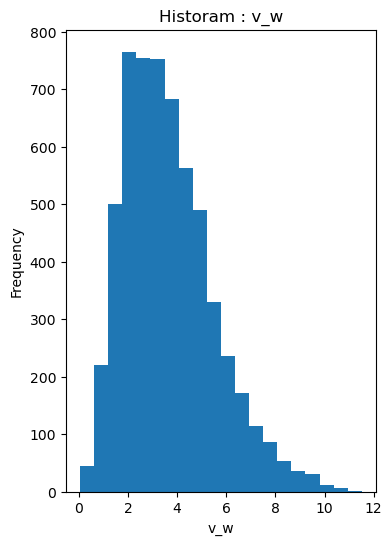

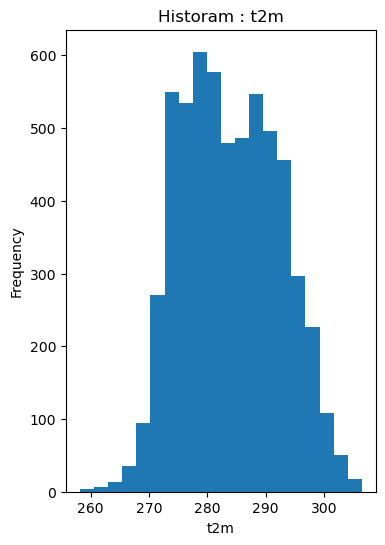

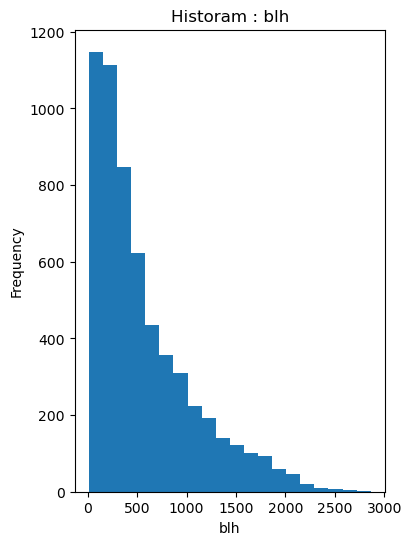

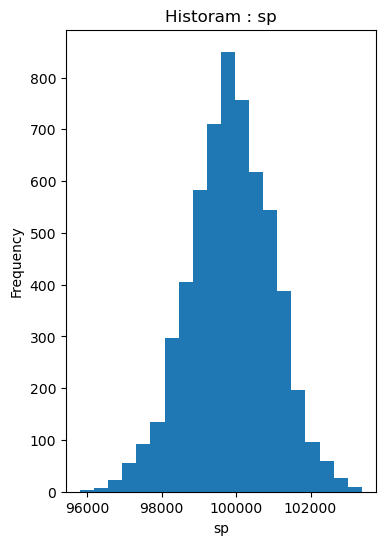

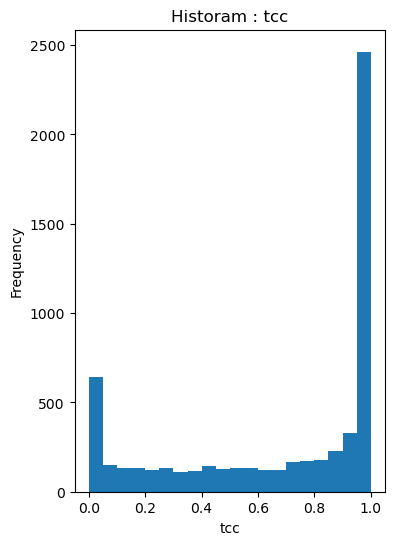

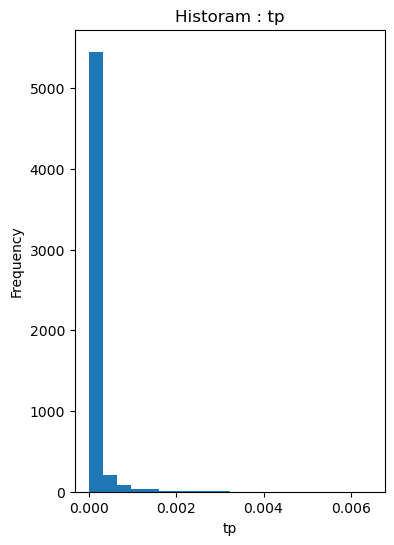

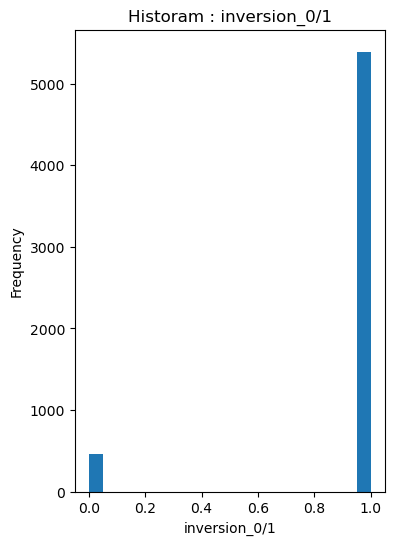

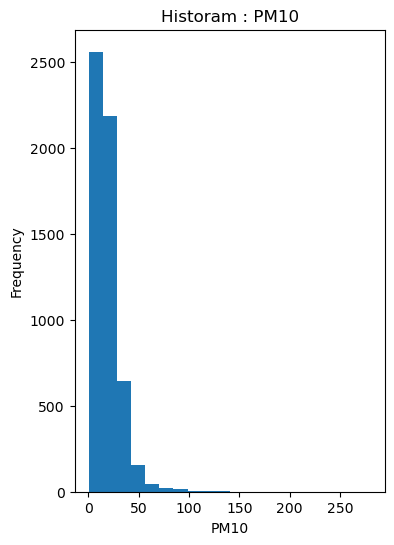

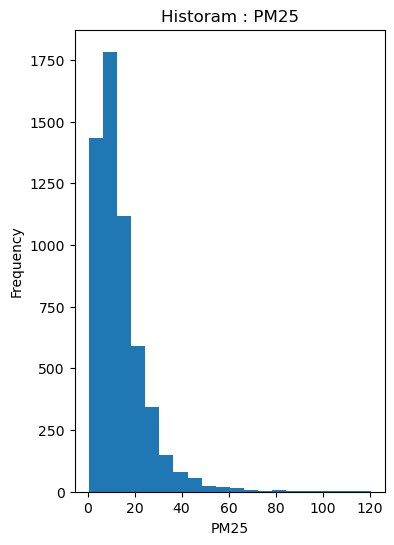

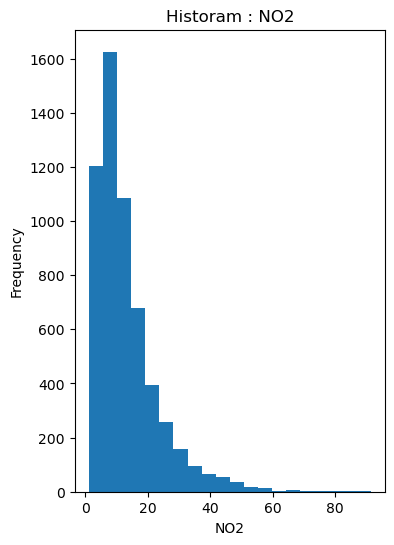

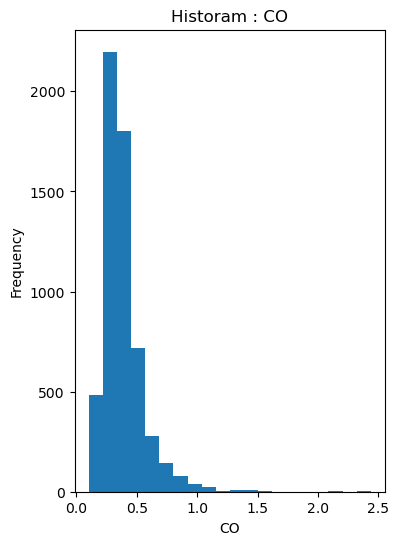

In [1133]:
for c in num_col:
    plt.figure(figsize = (4,6))
    plt.hist(main_df[c], bins = 20)
    plt.title(f'Historam : {c}')
    plt.xlabel(c)
    plt.ylabel('Frequency')
    plt.show()
    

#### 2.3.3. Analiza Outliery

Wnioski:

Nie usuwam żadnych outlierów, gdyż sa to dane realne , zdobyte zgodnie ze wskazaniami prawidłowo działjacych stacji meteorologicznych.
Każda wartosć będaca poza zakresem IQR to rzeczywiska obserwacja, więc usunięcie ich byłoby fałszowaniem danych.


In [1135]:
# nowy słownik do zicznia outlierów wg. nazw kolumn numerycznych 
outlier_counts = {}

# petla for do obliczenia iqr dla kazdej z numerycznych kolum i przypisania sumy outlierow w danej kolimnie + przypisanie do słownika
for c in num_col:
    q1 = main_df[c].quantile(0.25)
    q3 = main_df[c].quantile(0.75)
    iqr = q3-q1
    low = q1 - 1.5*iqr
    high = q3 + 1.5*iqr
    outlier_counts[c] = ((main_df[c] > high) | (main_df[c] < low)).sum()

# tworzymy nowy pandas Series prezetujacy slownik out_liers (w uporzadkowanej tabeli) a następnie transformacja do Data Frame
outliers_df = pd.Series(outlier_counts, name='n_outliers').sort_values(ascending=False)
display(pd.DataFrame(outliers_df))

,n_outliers
tp,1030
inversion_0/1,460
CO,327
NO2,300
blh,246
PM25,246
PM10,239
v_w,110
sp,44
t2m,0


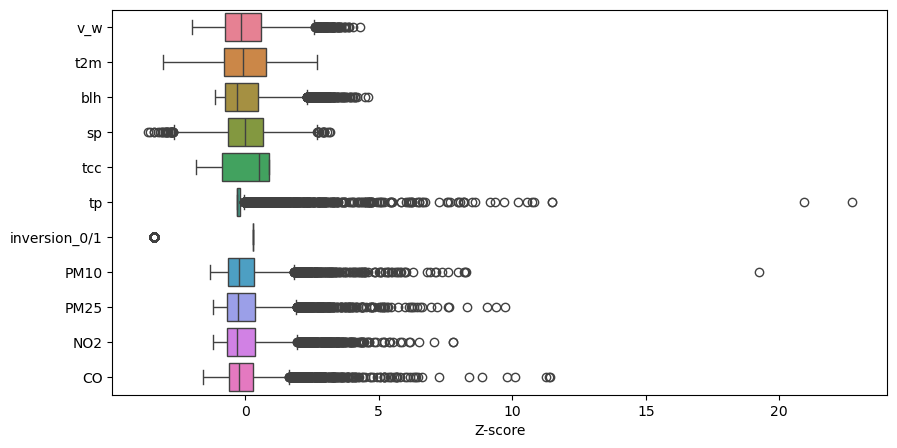


 ************************************************************************************************************************ 



In [1136]:
# tworzymy boxplot dla zmiennych z main_df do oceny wizualnej sytuacji outlierów.

num_df = main_df[num_col].copy()

# przy tworzeniu box plot, stosujemy wzrór na Z-sore tj. normalizaja, standaryzacje danych (przeskalownie)
# dla wyraźniejszego pokazania na wykresie rozkładu danych po przez wizualizację statystyk pozycujnych.
plt.figure(figsize=(10,5))
sns.boxplot((num_df-num_df.mean())/num_df.std(),orient='h')
plt.xlabel('Z-score')
plt.show()


print('\n','*'*120,'\n')


#### 2.3.4. Brakujace wartosci.

Dla brakujacych wartości , przed budowa modeli predkcyjnych bedzie trzeba zastosować IMPUTER

In [1138]:
df_nan = main_df[num_col].isna().sum().loc[lambda x: x>0].to_frame(name='NaN_count')
df_nan

,NaN_count
tp,4
PM10,207
PM25,216
NO2,149
CO,50


#### 2.3.5. Badanie korelacji cech


Wniosek : Z uwagi na wcześniejsza analiza czynników meteorologicznych majacych wpływ na poziom jakości powietrza na danym obszarze,
postanawiam nie usuwać, żednych z wymienionych cech numerycznych.

Ale w badaniu skuteczności modeli moze okazać się , że niektóre dane wymagaja usuniecia 

In [1805]:
corr_matrix = main_df_ext.corr(numeric_only=True)


In [1799]:
corr_target = corr_matrix.loc[num_col,target_col]


In [1801]:
# Korelacja ze zmiennymi cech dla PM10

corr_target['PM10'].drop(target_col).abs().sort_values(ascending=False).to_frame()

,PM10
blh,0.300148
inversion_0/1,0.290455
v_w,0.232759
t2m,0.183527
sp,0.164650
year,0.122986
tp,0.100629
tcc,0.033553
day,0.025091


In [1807]:
corr_target['PM25'].drop(target_col).abs().sort_values(ascending=False).to_frame()

,PM25
t2m,0.395419
blh,0.364563
inversion_0/1,0.336085
v_w,0.233192
sp,0.157197
year,0.078105
tp,0.075004
tcc,0.058758
day,0.030404


In [1144]:
corr_target['NO2'].drop(target_col).abs().sort_values(ascending=False).to_frame()


,NO2
blh,0.462399
v_w,0.320045
t2m,0.318168
sp,0.171976
inversion_0/1,0.167540
tp,0.061539
tcc,0.033292


In [1145]:
corr_target['CO'].drop(target_col).abs().sort_values(ascending=False).to_frame()

,CO
blh,0.358069
v_w,0.263620
t2m,0.229008
inversion_0/1,0.148963
sp,0.091698
tp,0.030180
tcc,0.022984


#### 2.3.6. Sprawdzenie duplikatów

##### Wniosek: 
Dane pochodza z profesjonalnego źródła, więc o ile na etapie importu i procesów przygotowania danych nie pojawiły się błędy , to nasz DataFrame nie powienien zawierać żednych duplikatów.

In [1147]:
main_df.duplicated().sum()

0

#### 2.3...... Wnioski / Podsumowanie 

#### 2.4. Agregeacja main_df
Rozszeżenie o potrzebne dane

#### 2.4.1. Dodanie nowych, niezbędnych kolumn.

In [1781]:
# Rozbicie daty/godziny 'time' na szczegóły i zapisanie w nowych kolumnach 


# rozbiecie 'time' na szczegóły, przypisanie do nowych kolumn wartosći - Rok / Miesiac / Dzień / Dzień_tyg / 
main_df_ext = main_df.assign(
    month=main_df['time'].dt.month_name(),
    year=main_df['time'].dt.year,
    day=main_df['time'].dt.day,
    hour=main_df['time'].dt.time,
    day_of_week=main_df['time'].dt.day_name())



In [1783]:
main_df_ext.to_csv('/Users/marcinurbanski/Desktop/merito_projekt_pliki_robocze/qualityair_projekt/0_ready_raw_data/main_df.csv')

<hr style="
height:50px;
border:none;
background: linear-gradient(to right, red, orange, yellow, green, blue, purple);
">

# STEP 3

## 3. Transformacja danych 

In [1821]:
# Wprowadzamy podział na dane numeryczne i zmienne kategoryczne 
num_col = main_df_ext.select_dtypes(include=['int64', 'float64','int32']).columns.tolist()
cat_col = main_df_ext.select_dtypes(include=['object']).columns.tolist()

# Wprowadzamy podział na cechy i cele modelów predykcyjnych .

# Lista kolumn cech i celów
target_col = ['PM10','PM25','NO2','CO']
num_feature_col = [c for c in main_df_ext.columns if c not in target_col and c not in cat_col and c != 'time' and c != 'tp' and c != 'tcc' and c != 'sp']
cat_feature_col = [c for c in main_df_ext.columns if c not in target_col and c not in num_col and c != 'city' and c != 'time']

# Data Frame dla cech i celów 
target_df = main_df_ext[target_col]
feature_df = main_df_ext[cat_feature_col+num_feature_col]


### 3.1. Walidacja daych celu - target_df

In [1601]:
# target_df.info()

In [1599]:
# target_df.isna().sum()

In [1825]:
# Uzupełnienie brakujacych wartości NaN na średnia.

target_df = target_df.fillna(target_df.mean())

### 3.1. Preprocessing

In [1827]:
# robimy podział na train / test dla całego data setu main_df

X_train, X_test, y_train, y_test = train_test_split(
    feature_df, target_df,
    test_size=0.2,
    random_state=42
) 

#### 3.1.1. Standard Scaller 

In [1841]:
# Wyznaczmy kolumny do transdormacji dla Linear Regression 
col_to_scale = [x for x in num_feature_col if x != 'inversion_0/1' and x != 'city' and x != 'time']
# dodanie metody jako zmiennej 
num_scaling = StandardScaler()

In [1843]:
col_to_scale

['v_w', 't2m', 'blh', 'year', 'day']

#### 3.1.2. Transformacja Logarytmiczna 

In [1845]:
# Wyznaczamy nazwy kolumn dla których zastosowana bedzie Transformacja Logarytmiczna , 
# na podstawie analizy wykonanej w punkcie 2.3.1.
skew_ls = skew_df['features'].to_list()
col_to_logtransform = [x for x in num_feature_col if x in skew_ls and x not in target_col]
# dodanie metody jako zmiennej 
num_logtransform =  FunctionTransformer(np.log1p)

In [1847]:
col_to_logtransform

['blh']

#### 3.1.3. Fill NaN

In [1849]:
# Wskazujemy kolumny zawierajace braki NaN. df_nan to odwołanie do widoku z punktu 2.3.3. Brakujace wartosci.
col_to_fillnan = [col for col in df_nan.index.to_list() if col not in target_col]
num_fillNaN = SimpleImputer(strategy='median')

In [1871]:
col_to_fillnan

['tp']

#### 3.1.3. One hot encoding

In [1855]:
col_to_ohe = cat_feature_col
cat_ohe = OneHotEncoder(handle_unknown='ignore')

In [1869]:
col_to_ohe

['month', 'hour', 'day_of_week']

### 3.2. Pipeline Preprocesing

#### 3.2.1. Linear Regresion Pipeline 

In [1857]:
num_311_313_prepro_LR = Pipeline(steps = [
    ('scaliing' , num_scaling),
    ('imputer', num_fillNaN)
])

num_312_prepro_LR  = Pipeline(steps = [
    ('logtrans' , num_logtransform),
    ('imputer', num_fillNaN)
])

cat_313_prepro_LR = Pipeline(steps = [
    ('onehot', cat_ohe)
])

### 3.2. Transformacja

#### 3.2.1. Transformacja Kolumn do Linear Regression

In [1873]:
lr_transform = ColumnTransformer(transformers=[
    ('num_scaling+fillNaN', num_311_313_prepro_LR ,col_to_scale),
    ('num_logtrans+fillNaN', num_312_prepro_LR, col_to_scale),
    ('cat_onehot', cat_313_prepro_LR, col_to_ohe)
])

lr_transform2 = ColumnTransformer(transformers=[
    ('cat_onehot', cat_313_prepro_LR, col_to_ohe)
])

## 4. Budowanie Modeli ML

### 4.1. Linear Regression

#### 4.1.1. Baseline Linear Regression 

In [1875]:
baseline_lr = Pipeline([
    ('preprocess', lr_transform),
    ('model', LinearRegression())
])

In [1877]:
baseline_lr.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_scaling+fillNaN', ...), ('num_logtrans+fillNaN', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the out

In [1879]:
y_pred_lr = baseline_lr.predict(X_test)

#### 4.1.2. Walidacja Linear Regression

In [1881]:
results = {}
for col in target_col:
    y_t = y_test[col]
    y_p = y_pred_lr[:, target_col.index(col)]
    mae  = mean_absolute_error(y_t, y_p)
    rmse = np.sqrt(mean_squared_error(y_t, y_p))
    r2   = r2_score(y_t, y_p)
    results[col] = {'MAE': round(mae,3), 'RMSE': round(rmse,3), 'R2': round(r2,3)}

metrics_df = pd.DataFrame(results).T
print(metrics_df)

        MAE   RMSE     R2
PM10  6.885  9.260  0.333
PM25  5.521  7.698  0.401
NO2   4.988  7.121  0.381
CO    0.102  0.148  0.305


In [1731]:
for col in target_col:
    cv_scores = cross_val_score(baseline_lr, feature_df, target_df[col],
                                cv=5, scoring='r2')
    print(f"{col}: CV R² = {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

PM10: CV R² = 0.021 ± 0.051
PM25: CV R² = 0.102 ± 0.046
NO2: CV R² = 0.046 ± 0.030
CO: CV R² = -0.296 ± 0.333


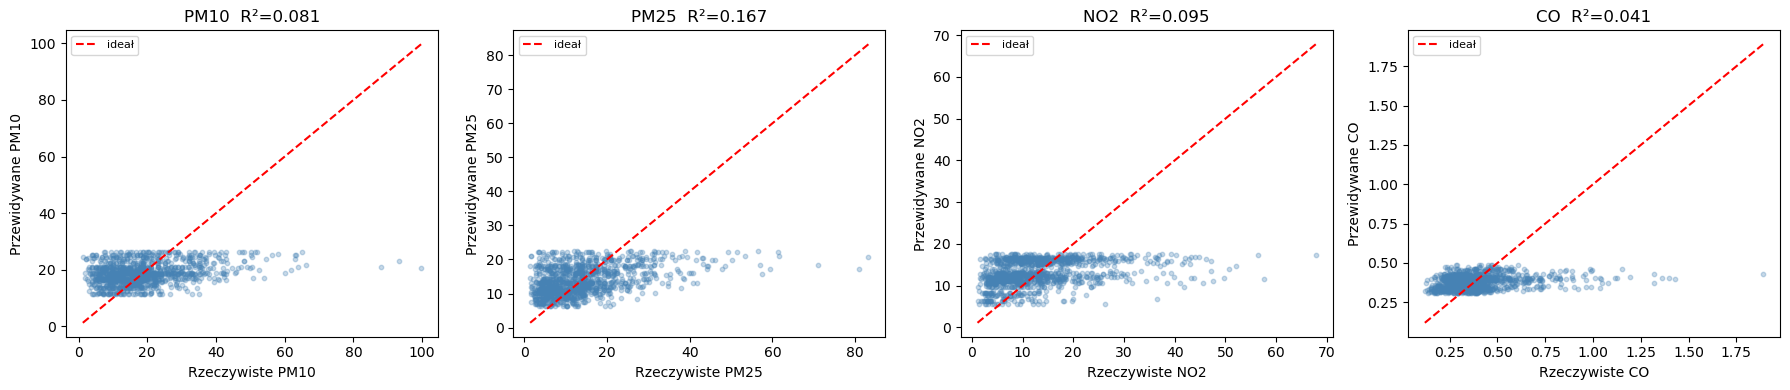

In [1733]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for i, col in enumerate(target_col):
    y_t = y_test[col].values
    y_p = y_pred_lr[:, i]
    axes[i].scatter(y_t, y_p, alpha=0.3, s=10, color='steelblue')
    lim = [min(y_t.min(), y_p.min()), max(y_t.max(), y_p.max())]
    axes[i].plot(lim, lim, 'r--', linewidth=1.5, label='ideał')
    axes[i].set_xlabel(f'Rzeczywiste {col}')
    axes[i].set_ylabel(f'Przewidywane {col}')
    axes[i].set_title(f'{col}  R²={r2_score(y_t,y_p):.3f}')
    axes[i].legend(fontsize=8)
plt.tight_layout()
plt.show()

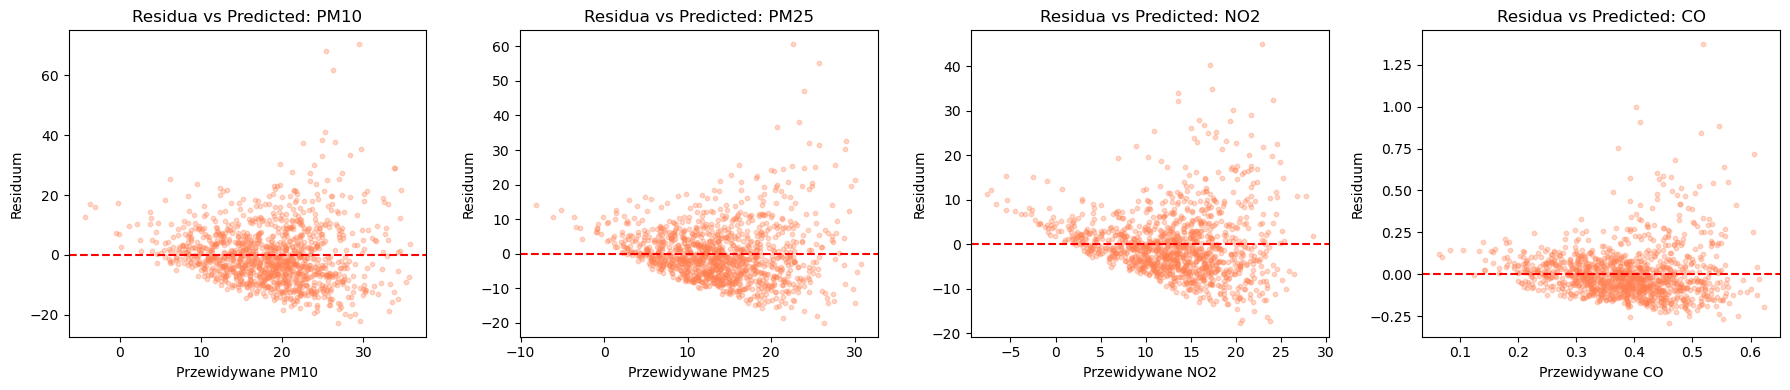

In [1713]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for i, col in enumerate(target_col):
    y_p = y_pred_lr[:, i]
    residuals = y_test[col].values - y_p
    axes[i].scatter(y_p, residuals, alpha=0.3, s=10, color='coral')
    axes[i].axhline(0, color='red', linestyle='--', linewidth=1.5)
    axes[i].set_xlabel(f'Przewidywane {col}')
    axes[i].set_ylabel('Residuum')
    axes[i].set_title(f'Residua vs Predicted: {col}')
plt.tight_layout()
plt.show()

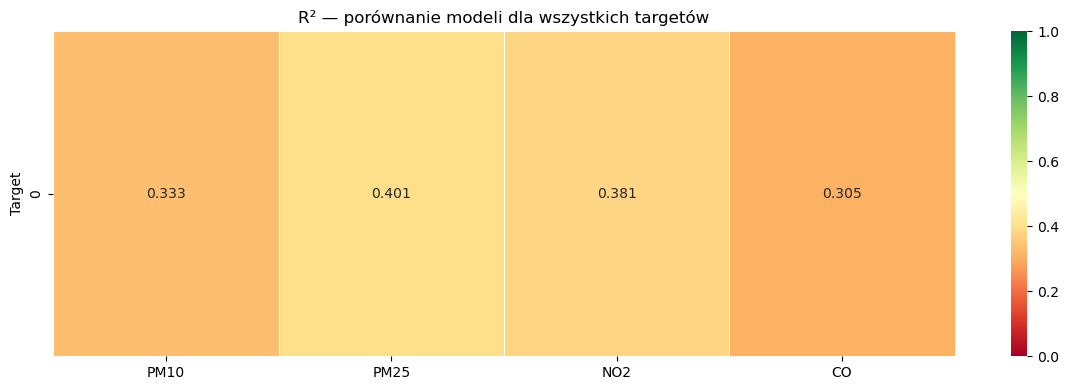

In [1883]:
import seaborn as sns


r2_matrix = pd.DataFrame({
    name: df['R2'] for name, df in results.items()
},index=[0])
plt.figure(figsize=(12, 4))
sns.heatmap(r2_matrix, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0, vmax=1, linewidths=0.5)
plt.title('R² — porównanie modeli dla wszystkich targetów')
plt.ylabel('Target')
plt.tight_layout()
plt.show()

### 4.2. XGBoost

#### 4.2.1. Baseline_XGB 

In [1896]:
model_xgb = XGBRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    objective='reg:squarederror', # cel: minimalizacja błędu kwadratowego
    random_state=42)

In [1902]:
baseline_XGB = Pipeline(steps=[
    ('preprocess', lr_transform),
    ('model', model_xgb)
])
    

In [1904]:
baseline_XGB.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_scaling+fillNaN', ...), ('num_logtrans+fillNaN', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the out

In [1906]:
y_pred_xgb = baseline_XGB.predict(X_test)

#### 4.2.2. Walidacja XG_Boost

In [1910]:
results_xgb = {}
for col in target_col:
    y_t = y_test[col]
    y_p = y_pred_xgb[:, target_col.index(col)]
    mae  = mean_absolute_error(y_t, y_p)
    rmse = np.sqrt(mean_squared_error(y_t, y_p))
    r2   = r2_score(y_t, y_p)
    results[col] = {'MAE': round(mae,3), 'RMSE': round(rmse,3), 'R2': round(r2,3)}

metrics_df_xgb = pd.DataFrame(results).T
print(metrics_df_xgb)

        MAE   RMSE     R2
PM10  6.099  9.105  0.355
PM25  4.810  7.292  0.462
NO2   4.303  6.281  0.519
CO    0.096  0.139  0.388


# SPRADZENIA 

In [1913]:
# X_train.isna().sum()

In [1915]:
# (main_df[feature_col]<0).any()

In [1917]:
# y_train.isna().sum()

In [1919]:
# main_df['inversion_0/1'].unique()
# main_df['inversion_0/1'].isna().sum()

# Możliwe Modele Do sprawdzenia

In [1921]:

# # ---- 4.0. Definicja modeli ----
# models = {
#     'LinearRegression' : LinearRegression(),
#     'Ridge'            : Ridge(alpha=1.0),
#     'Lasso'            : Lasso(alpha=0.1, max_iter=5000),
#     'ElasticNet'       : ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=5000),
#     'RandomForest'     : RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
#     'GradientBoosting' : MultiOutputRegressor(
#                             GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
#                                                       max_depth=4, random_state=42)),
#     'XGBoost'          : MultiOutputRegressor(
#                             XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5,
#                                          subsample=0.8, random_state=42, verbosity=0)),
#     'LightGBM'         : MultiOutputRegressor(
#                             LGBMRegressor(n_estimators=300, learning_rate=0.05, num_leaves=31,
#                                           random_state=42, verbose=-1)),
# }

# # ---- 4.1. Wspólny preprocessing (skalowanie + imputer + log dla LR-based) ----
# # Modele drzewiaste nie potrzebują skalowania — dla nich używamy surowego X
# # Dlatego tworzymy dwa zestawy danych:
# X_train_tree = X_train.copy()   # bez skalowania dla RF/XGB/LGBM
# X_test_tree  = X_test.copy()

# # ---- 4.2. Trening i ewaluacja wszystkich modeli ----
# results_all = {}

# for name, model in models.items():
#     # drzewiaste — bez preprocessingu
#     if name in ['RandomForest', 'GradientBoosting', 'XGBoost', 'LightGBM']:
#         model.fit(X_train_tree, y_train)
#         preds = model.predict(X_test_tree)
#     else:
#         # linearne — używamy pipeline z preprocessingiem
#         pipe = Pipeline([('preprocess', lr_transform), ('model', model)])
#         pipe.fit(X_train, y_train)
#         preds = pipe.predict(X_test)

#     # metryki dla każdego z 4 targetów
#     metrics = {}
#     for i, col in enumerate(target_col):
#         y_t = y_test[col].values
#         y_p = preds[:, i]
#         metrics[col] = {
#             'MAE' : round(mean_absolute_error(y_t, y_p), 3),
#             'RMSE': round(np.sqrt(mean_squared_error(y_t, y_p)), 3),
#             'R2'  : round(r2_score(y_t, y_p), 3)
#         }
#     results_all[name] = pd.DataFrame(metrics).T
#     print(f"\n{name}:\n{results_all[name]}")


# # ---- 4.3. Heatmapa porównawcza R² ----
# r2_matrix = pd.DataFrame({
#     name: df['R2'] for name, df in results_all.items()
# })

# plt.figure(figsize=(14, 4))
# sns.heatmap(r2_matrix, annot=True, fmt='.3f', cmap='RdYlGn',
#             vmin=0, vmax=1, linewidths=0.5, cbar_kws={'label': 'R²'})
# plt.title('R² — porównanie modeli dla wszystkich targetów')
# plt.ylabel('Target')
# plt.tight_layout()
# plt.show()


# # ---- 4.4. Feature importance (RandomForest jako przykład) ----
# rf_model = models['RandomForest']
# importances = pd.Series(rf_model.feature_importances_,
#                         index=X_train_tree.columns).sort_values(ascending=False)

# plt.figure(figsize=(10, 5))
# importances[:15].plot(kind='bar', color='steelblue', edgecolor='white')
# plt.title('Feature importance — RandomForest (top 15)')
# plt.ylabel('Importance')
# plt.tight_layout()
# plt.show()


# # ---- 4.5. Strojenie hiperparametrów — przykład dla XGBoost / PM10 ----
# from sklearn.model_selection import RandomizedSearchCV

# param_grid = {
#     'estimator__n_estimators'     : [100, 200, 300, 500],
#     'estimator__max_depth'        : [3, 4, 5, 6, 8],
#     'estimator__learning_rate'    : [0.01, 0.05, 0.1],
#     'estimator__subsample'        : [0.6, 0.7, 0.8, 1.0],
#     'estimator__colsample_bytree' : [0.6, 0.8, 1.0],
# }

# xgb_search = RandomizedSearchCV(
#     estimator  = MultiOutputRegressor(XGBRegressor(random_state=42, verbosity=0)),
#     param_distributions = param_grid,
#     n_iter     = 30,
#     cv         = 5,
#     scoring    = 'r2',
#     random_state = 42,
#     n_jobs     = -1,
#     verbose    = 1
# )
# xgb_search.fit(X_train_tree, y_train)

# print("Najlepsze parametry XGBoost:", xgb_search.best_params_)
# print("Najlepszy R² CV:", round(xgb_search.best_score_, 3))


LinearRegression:
        MAE   RMSE     R2
PM10  6.885  9.260  0.333
PM25  5.521  7.698  0.401
NO2   4.988  7.121  0.381
CO    0.102  0.148  0.305

Ridge:
        MAE   RMSE     R2
PM10  7.139  9.706  0.267
PM25  5.765  7.997  0.353
NO2   4.980  7.114  0.383
CO    0.103  0.149  0.296

Lasso:
        MAE   RMSE     R2
PM10  7.260  9.881  0.240
PM25  5.923  8.175  0.324
NO2   4.990  7.125  0.381
CO    0.119  0.177 -0.002

ElasticNet:
        MAE   RMSE     R2
PM10  7.315  9.926  0.233
PM25  5.941  8.200  0.320
NO2   5.007  7.139  0.378
CO    0.110  0.166  0.129


ValueError: could not convert string to float: 'April'